# Semana 4 – Técnicas de Optimización (Equipo)

Comparar 2 configuraciones de optimización (optimizador o LR).

## Evidencia esperada
- Comparación válida
- Evidencia visible
- Conclusiones

## Base

Definir modelo/dataset constantes.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

# Semillas para reproducibilidad (Requisito de calidad)
np.random.seed(7); tf.random.set_seed(7)

# Carga y preparación de datos (Basado en Código 1)
data = load_diabetes()
X, y = data.data, (data.target > np.median(data.target)).astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train); X_test_s = scaler.transform(X_test)

# Arquitectura Base Constante (Requisito: Comparación válida)
def build_model():
    return keras.Sequential([
        layers.Input(shape=(X_train_s.shape[1],)),
        layers.Dense(32, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])

print(f"Configuración base lista. Datos: {X_train_s.shape}")


Configuración base lista. Datos: (353, 10)


## Config A: SGD (Descenso por Gradiente Estocástico)


Entrenar config A y registrar resultados.

In [5]:
# Crear y compilar
model_a = build_model()
opt_a = keras.optimizers.SGD(learning_rate=0.01, momentum=0.0)
model_a.compile(optimizer=opt_a, loss="binary_crossentropy", metrics=["accuracy"])

# Entrenamiento (Registramos el historial 'h_a para las graficas')
h_a = model_a.fit(X_train_s, y_train, validation_split=0.2, epochs=50, batch_size=32, verbose=0)
# Evaluar
results_a = model_a.evaluate(X_test_s, y_test, verbose=0)

# Imprimir
print(f"SGD(lr=0.01) -> test loss/acc: {results_a} | last val_loss/val_acc: {h_a.history['val_loss'][-1]} {h_a.history['val_accuracy'][-1]}")


SGD(lr=0.01) -> test loss/acc: [0.5384763479232788, 0.7752808928489685] | last val_loss/val_acc: 0.5538699626922607 0.6619718074798584


## Config B: (Optimización Adaptativa)

Entrenar config B y registrar resultados.

In [7]:
# Crear y compilar
model_b = build_model()
opt_b = keras.optimizers.Adam(learning_rate=0.001)
model_b.compile(optimizer=opt_b, loss="binary_crossentropy", metrics=["accuracy"])

# Entrenamiento (Registramos el historial 'h_b')
h_b = model_b.fit(X_train_s, y_train, validation_split=0.2, epochs=50, batch_size=32, verbose=0)
results_b = model_b.evaluate(X_test_s, y_test, verbose=0)

# Imprimir
print(f"Adam(lr=0.001) -> test loss/acc: {results_b} | last val_loss/val_acc: {h_b.history['val_loss'][-1]} {h_b.history['val_accuracy'][-1]}")


Adam(lr=0.001) -> test loss/acc: [0.435861736536026, 0.8202247023582458] | last val_loss/val_acc: 0.494324266910553 0.7464788556098938


## Visualización

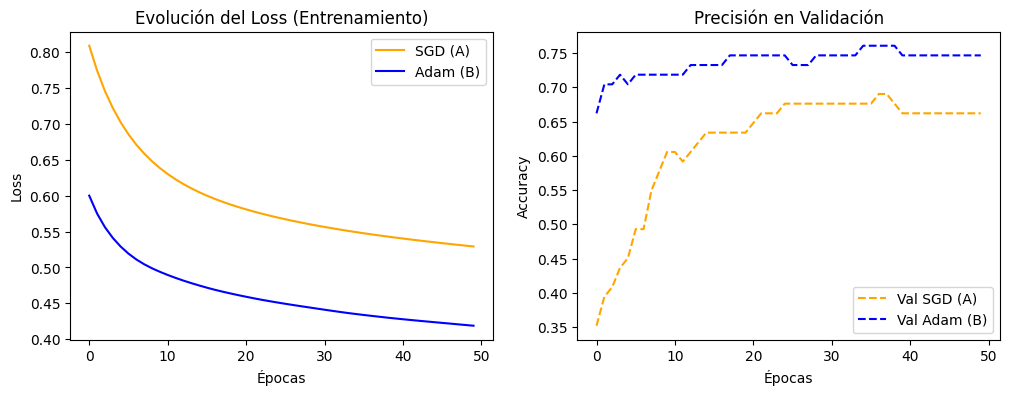

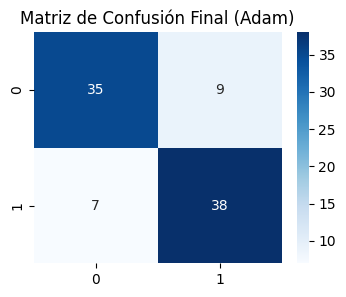

In [8]:
# 1. Gráfico de convergencia (Loss)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(h_a.history['loss'], label='SGD (A)', color='orange')
plt.plot(h_b.history['loss'], label='Adam (B)', color='blue')
plt.title('Evolución del Loss (Entrenamiento)')
plt.xlabel('Épocas'); plt.ylabel('Loss'); plt.legend()

# 2. Gráfico de Accuracy
plt.subplot(1, 2, 2)
plt.plot(h_a.history['val_accuracy'], label='Val SGD (A)', linestyle='--', color='orange')
plt.plot(h_b.history['val_accuracy'], label='Val Adam (B)', linestyle='--', color='blue')
plt.title('Precisión en Validación')
plt.xlabel('Épocas'); plt.ylabel('Accuracy'); plt.legend()
plt.show()

# 3. Matriz de Confusión (Para el reporte final)
pred_b = (model_b.predict(X_test_s, verbose=0) > 0.5).astype(int)
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, pred_b), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión Final (Adam)')
plt.show()


## Conclusiones

**TODO:** Estabilidad/velocidad con evidencia.